<a href="https://colab.research.google.com/github/Andreina-A/Data620/blob/main/Data620_project2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Andreina Arias
<br>Project 2
<br>1.Identify a large 2-node network dataset—you can start with a dataset in a repository.  Your data should meet the criteria that it consists of ties between and not within two (or more) distinct groups.
<br> 2.Reduce the size of the network using a method such as the island method described in chapter 4 of social network analysis.
<br> 3.What can you infer about each of the distinct groups?

<br> The Dataset I will be using for this assignment will be and amazon reviews file on electroinics, where one set of node represents users and the other represents products. A tie exists when a user reviews a product forming a bipartite network. I obtained the original data from Standford Large network website but they had an outdated verision that redirected me to: https://jmcauley.ucsd.edu/data/amazon/index_2014.html
<br> Since the data was very large, a subset of 50,00 reviews was used. The resulting network contained 36,074 users, 2,020 products, and 50,000 edges(reviews).

In [3]:
import pandas as pd
import gzip
import json
import requests
import io
import networkx as nx
from networkx.algorithms import bipartite
from networkx.algorithms.community import greedy_modularity_communities
import matplotlib.pyplot as plt
import random

#obtained the data directly from the website instead of downloading into my computer.
def stream_amazon_data(url, limit=50000):
    # Stream the file from the URL
    response = requests.get(url, stream=True)
    G = nx.Graph()
    count = 0

    # Use GzipFile to decompress the stream on the fly
    with gzip.GzipFile(fileobj=io.BytesIO(response.content)) as f:
        for line in f:
            d = json.loads(line)
            user = d['reviewerID']
            product = d['asin']

            # Add nodes with bipartite attribute
            G.add_node(user, bipartite=0)
            G.add_node(product, bipartite=1)
            G.add_edge(user, product)

            count += 1
            if count >= limit:
                break
    return G

# The 2014 Electronics 5-core URL, used 5 core because it would be a cleaner data for electronics that at least have 5 or more reviews
data_url = "http://snap.stanford.edu/data/amazon/productGraph/categoryFiles/reviews_Electronics_5.json.gz"
B = stream_amazon_data(data_url)

print(f"Nodes: {B.number_of_nodes()} | Edges: {B.number_of_edges()}")

Nodes: 38094 | Edges: 50000


To reduce the size and highlight meanginful relations, the bipartite netwokr was projected onto the product nodes. The edges represented shared reviewers the island method was then applied using a threshold of 3, meaning only edges with weight that were equaled to or greater than 3 were retained. This removes weaker connections and reveals stronger relationships between products.
After applying the island method:
21 connected components (islands) were identified
These islands represent clusters of products that are strongly related through shared user activity.

In [35]:
#reduced size using island method

#product node
products= {n for n,d in B.nodes(data=True) if d['bipartite']==1}
#created edges between products that share reviewers
P=bipartite.weighted_projected_graph(B,products)

#island method
def islands_method(G, threshold):
  #removed edges below the "water level" to reveal meaningful results (from chap 4 of social network analysis startup)
  strong_edges= [(u,v) for u,v,d in G.edges(data=True) if d['weight']>=threshold]

  #created a new graph with only the strong ties
  G_islands=nx.Graph()
  G_islands.add_edges_from(strong_edges)

  return G_islands


In [36]:
#tried a threshold of 3 to find products frequently reviewed or bought together
threshold_level=3
electronics_islands=islands_method(P,threshold_level)
print(f"Islands at threshold {threshold_level}: {nx.number_connected_components(electronics_islands)}")

Islands at threshold 3: 21


The degree distribution of users showed that most users reviewed only a small number of products, while a small number of users reviewed many products. This is why the graph was highly skewed distribution, where a few highly active users contribute disproportionately to the network.
The edge weight distribution in the projected product network shows that most product pairs share only a small number of reviewers. Strong ties between products are relatively rare, but they represent more meaningful relationships.
The component size distribution further shows that most islands are very small, while only a few larger clusters exist. This suggests that most products are weakly connected, while a smaller number form tightly related groups.

In [37]:
#exploratory data analysis of the network
users= {n for n,d in B.nodes(data=True) if d['bipartite']==0}
products= {n for n,d in B.nodes(data=True) if d['bipartite']==1}

print("Number of users:", len(users))
print("Number of products:", len(products))
print("total edges (reviews):", B.number_of_edges())

Number of users: 36074
Number of products: 2020
total edges (reviews): 50000


In the histograph below it was seen that most users reviewed very few products.

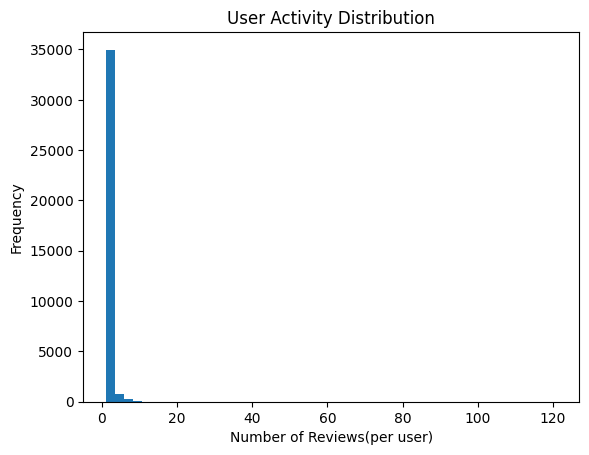

In [38]:
#visual of degree distribution
user_degree=[B.degree(u) for u in users]

plt.hist(user_degree, bins=50)
plt.xlabel("Number of Reviews(per user)")
plt.ylabel("Frequency")
plt.title("User Activity Distribution")
plt.show()



The histogram on edge weight distribution show that most product pair share only a few reviewer, the strong are meaningful but seem to be rare.

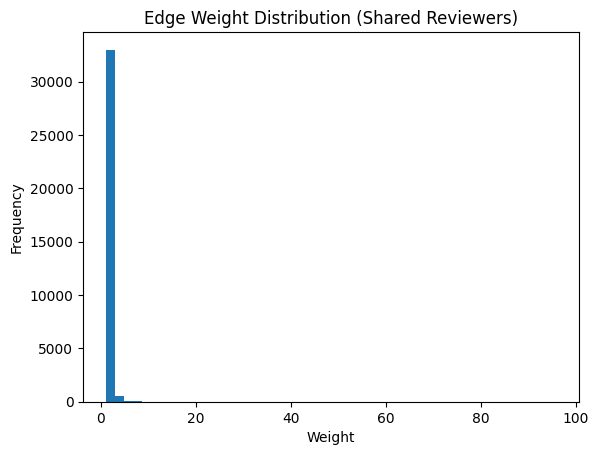

In [39]:
#edge weight distribution
weights = [d['weight'] for _,_, d in P.edges(data=True)]
plt.hist(weights, bins=50)
plt.xlabel("Weight")
plt.ylabel("Frequency")
plt.title("Edge Weight Distribution (Shared Reviewers)")
plt.show()

The histogram of the island size distribution seems to show that users don't review many overlapping products since about 0-10 components have a frequency of about 20 and about 350 components have a frequency of about 1-2.

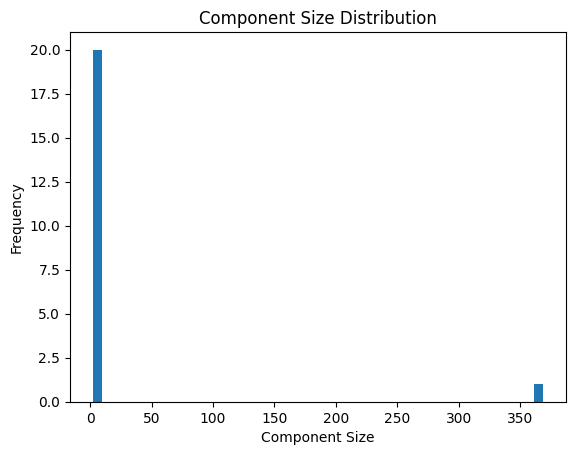

In [42]:
#component size distribution
component_sizes = [len(c) for c in nx.connected_components(electronics_islands)]
plt.hist(component_sizes, bins=50)
plt.xlabel("Component Size")
plt.ylabel("Frequency")
plt.title("Component Size Distribution")
plt.show()

In the network graph after island filtering it was seen that 35 communities of products. Each community represents the products frequently reviewed by the same users which likely belong to the same category.

Number of communities: 35


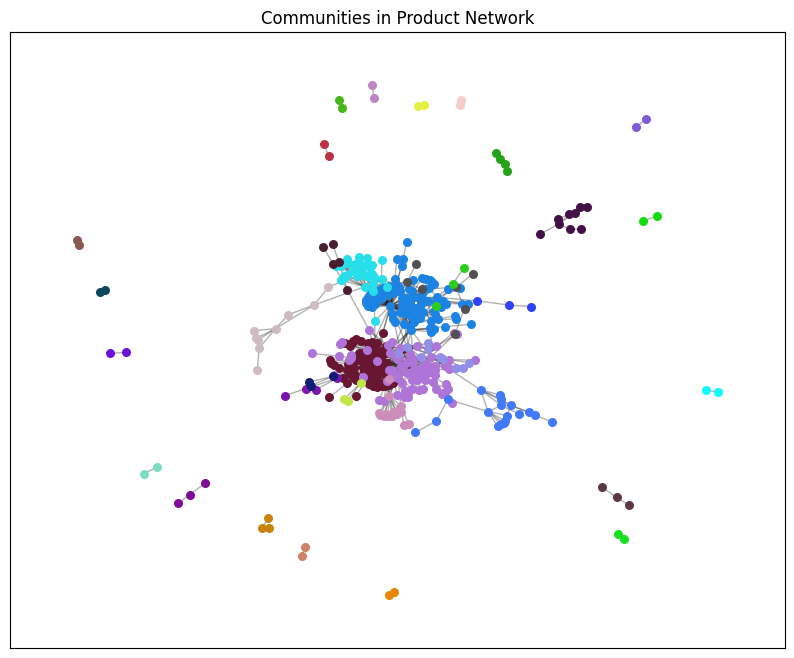

In [41]:
communities = list(greedy_modularity_communities(electronics_islands))

print("Number of communities:", len(communities))

#visual of communities
plt.figure(figsize=(10, 8))
pos = nx.spring_layout(electronics_islands)

for community in communities:
    nx.draw_networkx_nodes(
        electronics_islands, pos,
        nodelist=list(community),
        node_size=30,
        node_color=[(random.random(), random.random(), random.random())] #different color by commmunities
    )

nx.draw_networkx_edges(electronics_islands, pos, alpha=0.3)
plt.title("Communities in Product Network")
plt.show()

Overall, 21 islands connected components and 35 communities were found which could mean that come islands contained multiple subgroups. This indicate that even within strongly connected products. For example a larger electronics cluster may contain smaller comunities such as headphones, chargers, or computer accessories. The results show that the network has a layered structure, the higher level the island method revealed broad grouping of the related products while the cummunity detection uncovered more detailed subcatergories within those groups. This reflects how users interact with products while come items are broadly related, more specific patterns of user behavior reveal finer distinction between prduct types. This demonstrated that user review behavior not only connects productws broadly but also reveals detailed and meaningful substructures within the electronics market. What I can infer about each of the distinct groups is that the network consists of two distinct groups which are the users and products, and analyzing the bipartite network and its projections, several patterns emerged about the behavior of each group and their relationships.